In [57]:
import pandas as pd
import random

In [58]:
O, C, L, H = 90, 115, 89, 115

In [59]:
T = 60 # Cantidad de particiones de la vela (H / s)
n_iters = 100

In [2]:
import time
from IPython.display import clear_output

n_iters = 10
for i in tqdm.tqdm(range(n_iters)):
    # 1. Borra el contenido previo de la celda de salida
    clear_output(wait=True) 
    
    # 2. Imprime el nuevo texto de forma normal
    print(f"Cargando... {i}")
    
    time.sleep(1)

Cargando... 9


100%|██████████| 10/10 [00:10<00:00,  1.00s/it]


In [1]:
import tqdm
from time import sleep
n_iters = 10
for i in tqdm.tqdm(range(n_iters)):
    print(f'Iteración {i}', end = '\r') 
    
    sleep(2)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:02<00:18,  2.01s/it]

 20%|██        | 2/10 [00:04<00:16,  2.01s/it]

 30%|███       | 3/10 [00:06<00:14,  2.00s/it]

 40%|████      | 4/10 [00:08<00:12,  2.00s/it]

...

 60%|██████    | 6/10 [00:12<00:08,  2.00s/it]

 70%|███████   | 7/10 [00:14<00:06,  2.00s/it]

 80%|████████  | 8/10 [00:16<00:04,  2.00s/it]

 90%|█████████ | 9/10 [00:18<00:02,  2.00s/it]

100%|██████████| 10/10 [00:20<00:00,  2.00s/it]


# Propuesta 2 (Ocupando ángulos)

In [60]:
from itertools import product
import numpy as np

In [61]:
def arcotangente(opuesto, adyacente):
    if adyacente == 0:
        return np.inf
    return np.arctan(opuesto / adyacente)  * 180 / np.pi

In [62]:
import sys
import tqdm

0it [00:00, ?it/s]

3481it [00:00, 24491.10it/s]


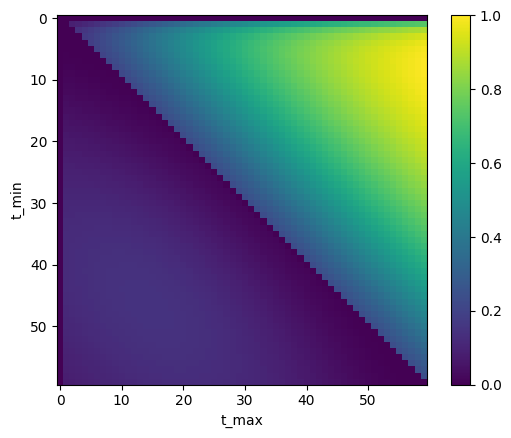

In [63]:
# Para cada combinacion t_min, t_max:
dic_p = {}
p_min, p_max = np.inf, -np.inf
d_min, d_max = np.inf, -np.inf
for t_min, t_max in tqdm.tqdm(product(range(1, T), range(1, T))):
    if t_min == t_max:
        continue
    if t_min > t_max:
        # alpha es el angulo entre los segmentos (0, O)-(t_max, H) y (0, H)-(t_max, H)
        adyacente, opuesto = t_max, H - O
        # alpha = atan(opuesto / adyacente)
        alpha = arcotangente(opuesto, adyacente)
        d1 = (adyacente ** 2 + opuesto ** 2) ** 0.5
        # beta es el angulo entre los segmentos (t_max, H)-(t_min, L) y (t_max, H)-(t_min, H)
        adyacente, opuesto = t_min - t_max, H - L
        # beta = atan(opuesto / adyacente)
        beta = arcotangente(opuesto, adyacente)
        d2 = (adyacente ** 2 + opuesto ** 2) ** 0.5
        
        # gamma es el angulo entre los segmentos (t_min, L)-(T, C) y (t_min, L)-(T, L)
        adyacente, opuesto = T - t_min, C - L
        # gamma = atan(opuesto / adyacente)
        gamma = arcotangente(opuesto, adyacente)
        d3 = (adyacente ** 2 + opuesto ** 2) ** 0.5
    else:
        # alpha es el angulo entre los segmentos (0, O)-(t_min, L) y (0, L)-(t_min, L)
        adyacente, opuesto = t_min, O - L
        # alpha = atan(opuesto / adyacente)
        alpha = arcotangente(opuesto, adyacente)
        d1 = (adyacente ** 2 + opuesto ** 2) ** 0.5
        # beta es el angulo entre los segmentos (t_min, L)-(t_max, H) y (t_min, L)-(t_max, L)
        adyacente, opuesto = t_max - t_min, H - L
        # beta = atan(opuesto / adyacente)
        beta = arcotangente(opuesto, adyacente)
        d2 = (adyacente ** 2 + opuesto ** 2) ** 0.5
        # gamma es el angulo entre los segmentos (t_max, H)-(T, C) y (t_max, H)-(T, H)
        adyacente, opuesto = T - t_max, H - C
        # gamma = atan(opuesto / adyacente)
        gamma = arcotangente(opuesto, adyacente)
        d3 = (adyacente ** 2 + opuesto ** 2) ** 0.5
    
    d = d1 + d2 + d3 #alpha + 2 * beta + gamma
    p = alpha + 2 * beta + gamma
    #print(t_min, t_max, p)
        
    if (alpha < 0) or (beta < 0) or (gamma < 0):
        sys.exit()
    
    
    dic_p[(t_min, t_max)] = (p, d)
    
    if p > p_max:
        p_max = p
    if p < p_min:
        p_min = p
    if d > d_max:
        d_max = d
    if d < d_min:
        d_min = d

lamda = 0.0005
# Dado que para cada par i, j tengo un valor p, grafica en una matriz de calor los valores de p
import matplotlib.pyplot as plt
matrix = np.zeros((T, T))

b = 2

for (t_min, t_max), (p, d) in dic_p.items():
    matrix[t_min, t_max] = ((1 - (p - p_min) / (p_max - p_min)) + lamda * (1 - (d - d_min) / (d_max - d_min))) ** b # Se eleva a b, como un calibrador.Si b = 2, se premian los resultados más probables
    
# cmap de rojo a verde
#plt.imshow(matrix, cmap='RdYlGn', interpolation='nearest')
plt.imshow(matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
# axis
plt.xlabel('t_max')
plt.ylabel('t_min')
plt.show()


Solo prueba empírica

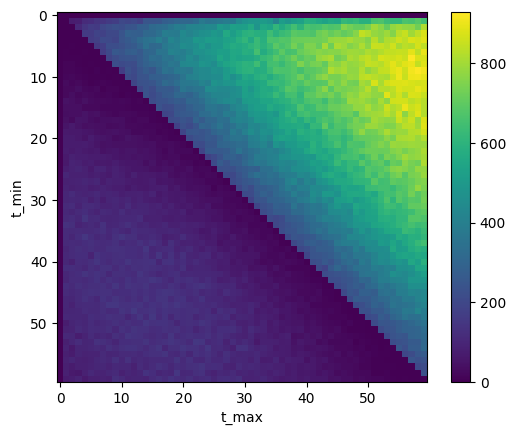

In [64]:
# Toma un valor aleatorio [i, j] donde el peso de la probabilidad es mayor, es decir, donde matrix[i, j] es mayor
def elegir_t_min_t_max(matrix):
    flat_matrix = matrix.flatten()
    probabilities = flat_matrix / flat_matrix.sum()
    index = np.random.choice(len(flat_matrix), p=probabilities)
    t_min, t_max = divmod(index, T)
    return t_min, t_max


matrix_muestral = np.zeros((T, T))
for j in range(10000):
    t_min, t_max = elegir_t_min_t_max(matrix)
    #print(t_min, t_max, dic_p[(t_min, t_max)])
    matrix_muestral[t_min, t_max] += 1

#matrix_muestral = matrix_muestral / matrix_muestral.sum()
            
plt.imshow(matrix_muestral, cmap='viridis', interpolation='nearest')
#plt.imshow(matrix_muestral, cmap='viridis', interpolation='nearest', origin='lower')
plt.colorbar()
plt.xlabel('t_max')
plt.ylabel('t_min')
plt.show()



In [82]:
t_min, t_max = elegir_t_min_t_max(matrix)
t_min, t_max

(21, 48)

In [66]:
sys.exit()

SystemExit: 

c:\Users\mvaldiviad\AppData\Local\anaconda3\envs\revenAI\Lib\site-packages\IPython\core\interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Propuesta 1

In [ ]:
#1. Seleccionar un aleatorio para el minimo (random 0, T)
t_min = random.randint(0, T)
print(t_min)

for iter in range(n_iters):
    # L1 es una recta que pasa por los puntos (0, O) y (t_min, L)
    L1 = lambda t: O + (L - O) * t / t_min
    # L2 es una recta que pasa por los puntos (t_min, L) y (T, C)
    L2 = lambda t: L + (C - L) * (t - t_min) / (T - t_min)

    dic_P1 = {}
    for t in range(T + 1):
        if t <= t_min:
            dic_P1[t] = L1(t)
        else:
            dic_P1[t] = L2(t)

    dic_P2 = {}
    for t in range(T + 1):
        min_value = T
        for t_ in (0, T, t_min):
            dist = abs(t - t_)
            if dist < min_value:
                min_value = dist
        dic_P2[t] = min_value

    dic_P = {}
    for t in range(T + 1):
        dic_P[t] = (dic_P1[t] / (H - L)) * (dic_P2[t] / T)

    dic_P

    # Dado que dic_P tiene las probabilidades para t_max, entonces obtenemos t_max con random.choices() usando dic_P como pesos
    t_max = random.choices(list(dic_P.keys()), weights=list(dic_P.values()), k=1)[0] # k=1 para obtener un solo valor, [0] porque se crea una lista de un valor (k=1)

    # Ahora lo mismo para el minimo

    # L1 es una recta que pasa por los puntos (0, O) y (t_max, H)
    L1 = lambda t: O + (H - O) * t / t_max
    # L2 es una recta que pasa por los puntos (t_max, H) y (T, C)
    L2 = lambda t: H + (C - H) * (t - t_max) / (T - t_max)

    dic_P1 = {}
    for t in range(T + 1):
        if t <= t_max:
            dic_P1[t] = H - L1(t)
        else:
            dic_P1[t] = H - L2(t)

    dic_P2 = {}
    for t in range(T + 1):
        min_value = T
        for t_ in (0, T, t_max):
            dist = abs(t - t_)
            if dist < min_value:
                min_value = dist
        dic_P2[t] = min_value

    dic_P = {}
    for t in range(T + 1):
        dic_P[t] = (dic_P1[t] / (H - L)) * (dic_P2[t] / T)

    t_min = random.choices(list(dic_P.keys()), weights=list(dic_P.values()), k=1)[0]
    print(iter, t_min, t_max)
    
t_min, t_max